In [ ]:
from scipy.io import loadmat
import numpy as np
# 加载 .mat 文件
import matplotlib.pyplot as plt
GNSS_data = loadmat('workbench/workbench/Earthquake_predictor/reference_project/RSIT/GNSS_South_central_Alaska_20180101_20181231.mat')['GNSS_South_central_Alaska_20180101_20181231']
earthquake_data = loadmat('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/South_central_Alaska_earthquake_event.mat')['South_central_Alaska_earthquake_event']

In [ ]:
def myLeakyRelu(x, leak, flag):
    """
    Apply LeakyReLU activation function.

    Args:
        x (ndarray): Input data.
        leak (float): Slope for negative values.
        flag (int): 1 for standard LeakyReLU, 2 for inverse LeakyReLU.

    Returns:
        ndarray: Activated output.
    """
    myleak = leak if flag == 1 else 1 / leak
    output = np.where(x >= 0, x, myleak * x)
    return output

In [ ]:

def NN_transform(traindata, weights):
    """
    Transform data using a neural network structure.

    Args:
        traindata (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata.shape
    output = np.zeros((weights[-1].shape[1], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata[:, i]  # Input for the current timestep
        for weight in weights:
            curr_layer_nodes_value = np.dot(pre_layer_nodes_value, weight)
            # Apply activation function (tanh or LeakyReLU)
            curr_layer_nodes_value = np.tanh(curr_layer_nodes_value / 3.0)
            curr_layer_nodes_value = myLeakyRelu(curr_layer_nodes_value, leak=0.01, flag=1)
            pre_layer_nodes_value = curr_layer_nodes_value
        output[:, i] = curr_layer_nodes_value  # Store result for this timestep
    
    return output

In [ ]:
def NN_transform_reverse(traindata_NN, weights):
    """
    Reverse transform using a neural network structure.

    Args:
        traindata_NN (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Reverse transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata_NN.shape
    output = np.zeros((weights[0].shape[0], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata_NN[:, i]
        for weight in reversed(weights):
            pre_layer_nodes_value = myLeakyRelu(np.dot(pre_layer_nodes_value, weight.T), leak=0.01, flag=1)
        output[:, i] = pre_layer_nodes_value
    
    return output

In [ ]:
def weights_align1(weight_a, weight_b, weight_c, input_dimension):
    """
    Generate weights for the neural network.

    Args:
        weight_a, weight_b, weight_c (int): Number of nodes in each layer.
        input_dimension (int): Input dimension.

    Returns:
        tuple: (all_weights, reverse_all_weights), both are lists of weight matrices.
    """
    post_nodes_num = [weight_a, weight_b, weight_c]
    layer_nodes_num = [input_dimension] + post_nodes_num
    
    all_weights = []
    reverse_all_weights = []
    
    for l in range(1, len(layer_nodes_num)):
        weight_matrix = np.random.randn(layer_nodes_num[l - 1], layer_nodes_num[l])
        all_weights.append(weight_matrix)
        reverse_all_weights.append(np.linalg.pinv(weight_matrix))
    
    return all_weights, reverse_all_weights

In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 设置随机数种子
import random

# 初始化参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix_databeihaidao1 = GNSS_data.T[:,:sample_use]

# 计算时间点
timepoint = sample_use - samples + 1

# 初始化变量
normal_sd_y = np.zeros((timepoint, 1))
normal_sd_original = np.zeros((stationnum, timepoint))
critical_sd_y = 0
ii = 0
good_ii = 0
reps = 0
nreps = 0


# 主循环，执行10000次迭代
while ii < 10:
    ii += 1
    input_dimensions = stationnum

    # 获取权重矩阵
    all_weights, reverse_all_weights = weights_align1(weight_a, weight_b, weight_c, altitude_matrix_databeihaidao1.shape[0])

    # 样本的关键区域
    critical_zone = np.arange(sample_use - samples, sample_use)

    normal_start = 0

    # 内部循环，遍历所有可能的正常区域
    while normal_start + samples - 1 < sample_use:
        normal_start += 1
        normal_zone = np.arange(normal_start - 1, normal_start + samples - 1)
        myzone = [normal_zone]
        # 计算正常区域的标准差
        normal_sd_original[:, normal_start - 1] = np.std(altitude_matrix_databeihaidao1[:, myzone[0]], axis=1, ddof=0)
    
        for mys in range(1):
            UU = altitude_matrix_databeihaidao1[:, myzone[mys]]

            input_dimensions, time_points = UU.shape # 16, 11

            flat_y = np.zeros((time_points + embeddings_num - 1, 1))
            xx = UU
            noisestrength = 0  # 可以添加噪声
            xx_noise = xx + noisestrength * np.random.rand(*xx.shape)
            D = xx_noise.shape[0]  # 系统中的变量数量 16
            trainlength = time_points

            traindata = xx_noise[:, :trainlength]

            traindata_x_NN = NN_transform(traindata, all_weights)
            test_NN = traindata_x_NN #(5, 11)
            
            F_dimensions = traindata_x_NN.shape[0]

            # 求解权重矩阵A
            AA_rows = (trainlength - 1) * (embeddings_num - 1) + 1
            AA_cols = embeddings_num * F_dimensions

            AA = np.zeros((AA_rows, AA_cols)) #41, 25
            b = np.zeros((AA_rows, 1))

            for k in range(embeddings_num - 1):
                for t in range(1, trainlength):
                    row_idx = k * (trainlength - 1) + t - 1
                    AA[row_idx, k * F_dimensions: (k + 1) * F_dimensions] = traindata_x_NN[:, t]
                    AA[row_idx, (k + 1) * F_dimensions: (k + 2) * F_dimensions] = -traindata_x_NN[:, t - 1]

            AA[(trainlength - 1) * (embeddings_num - 1), 0:F_dimensions] = traindata_x_NN[:, 1]
            b[(trainlength - 1) * (embeddings_num - 1), 0] = traindata_x_NN[0, 0]

            # 求解线性方程 AA * flat_A = b

            flat_A, residuals, rank, s_vals = np.linalg.lstsq(AA, b, rcond=None)

            flat_A = flat_A.flatten()

            weight_A = np.zeros((embeddings_num, F_dimensions))
            for i in range(embeddings_num):
                weight_A[i, :] = flat_A[i * F_dimensions: (i + 1) * F_dimensions]

            # 计算Y
            Y = np.dot(weight_A, traindata_x_NN)  # Y的大小为 (embeddings_num, trainlength)

            # 计算权重矩阵B
            B = np.dot(traindata_x_NN, np.linalg.pinv(Y))
            X_real = xx_noise[:, :trainlength]
            II = np.dot(weight_A, B)

            for t in range(trainlength):
                min_val = min(t + 1, embeddings_num)
                for j in range(min_val):
                    m = t - j
                    l = j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= min_val

            for t in range(trainlength, trainlength + embeddings_num - 1):
                max_j = embeddings_num - (t - trainlength)
                for j in range(max_j):
                    m = trainlength - j - 1
                    l = t - trainlength + j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= max_j

            # 计算标准差
            if 'sd1' not in locals():
                sd1 = np.zeros((1, flat_y.shape[0]))
                test_flat_y = np.zeros((1, flat_y.shape[0]))
            sd1[mys, :] = np.std(flat_y, axis=0, ddof=0)
            test_flat_y[mys, :] = flat_y.flatten()

        normal_sd_y[normal_start - 1, 0] += np.std(test_flat_y[0, :], ddof=0)
        reps += 1
    # 打印进度
    if ii % 100 == 0:
        print(ii)

# 计算平均标准差
normal_sd_y = normal_sd_y / ii

# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.show()

In [ ]:
import numpy as np

def NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e, traindata):
    """
    Implements the NN_F2 function to simulate a simple feedforward neural network.

    Parameters:
    - weight_a, weight_b, weight_c, weight_d, weight_e: Weights specifying the number of nodes in each layer.
    - traindata: Input data matrix of shape (input_dimension, trainlength).

    Returns:
    - output: Output of the neural network of shape (layer_nodes_num[-1], trainlength).
    """
    layer_nodes_num = [weight_a, weight_b, weight_c, weight_d, weight_e]
    input_dimension, trainlength = traindata.shape
    pre_layer_nodes_num = input_dimension

    # Initialize weights for all layers
    all_weights = {}
    for l in range(len(layer_nodes_num)):
        curr_layer_nodes_num = layer_nodes_num[l]
        for it in range(curr_layer_nodes_num):
            curr_node_input_weight = np.random.randn(pre_layer_nodes_num)
            all_weights[(l, it)] = curr_node_input_weight
        pre_layer_nodes_num = curr_layer_nodes_num

    # Forward pass through the network
    output = np.zeros((layer_nodes_num[-1], trainlength))
    for i in range(trainlength):
        pre_layer_nodes_num = input_dimension
        pre_layer_nodes_value = traindata[:, i]  # Input for the current sample

        for l in range(len(layer_nodes_num)):
            curr_layer_nodes_num = layer_nodes_num[l]
            curr_layer_nodes_value = []
            for it in range(curr_layer_nodes_num):
                curr_node_input_weight = all_weights[(l, it)]
                xx = np.sum(pre_layer_nodes_value * curr_node_input_weight)
                curr_layer_nodes_value.append(np.tanh(xx / 2.5))
            pre_layer_nodes_value = np.array(curr_layer_nodes_value).reshape(-1)
            pre_layer_nodes_num = curr_layer_nodes_num

        output[:, i] = pre_layer_nodes_value

    return output

In [ ]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
from multiprocessing import Pool, cpu_count

# 假设 GNSS_data 和 sample_use 已经定义
altitude_matrix_data = GNSS_data.T[:, :sample_use]

window_len = 4
newdata = np.zeros((altitude_matrix_data.shape[0],
                    altitude_matrix_data.shape[1] - window_len + 1))

for i in range(newdata.shape[1]):
    newdata[:, i] = np.mean(altitude_matrix_data[:, i:i + window_len], axis=1)

# 初始化参数
predict_len = 4
trainlength = 9
noisestrength = 0
X = altitude_matrix_data

weight_a = 400
weight_b = 300
weight_c = 200
weight_d = 100
weight_e = 100

# 定义目标站点
aim_station = list(range(1, 17))

# 设置随机种子以保证可重复性
np.random.seed(42)


# 定义处理单个站点的函数
def process_station(args):
    tt, jd = args
    pcc_y = []
    Loss_y = []
    rmse_y = []
    ii = 0

    while X.shape[1] - ii >= predict_len + trainlength:
        ii += 1
        xx = X[:, ii:]
        traindata = xx[:, :trainlength]
        k = 30
        real_y = xx[jd - 1, :]
        all_real_y = X[jd - 1, :]

        traindata_y = real_y[:trainlength]

        # 生成 NN_train 数据
        traindata_x_NN = np.zeros((weight_e, trainlength))

        for i in range(trainlength):
            traindata_x_NN[:, i] = NN_F2(weight_a, weight_b, weight_c, weight_d, weight_e,
                                         traindata[:, i].reshape(-1, 1)).flatten()

        # 初始化权重矩阵
        w_flag = np.zeros(traindata_x_NN.shape[0])
        B_w = np.zeros((traindata_x_NN.shape[0], predict_len))

        # 计算系数矩阵 B
        for _ in range(10):
            available_indices = np.setdiff1d(range(traindata_x_NN.shape[0]), [jd - 1])
            if len(available_indices) < k - 1:
                random_idx = available_indices
            else:
                random_idx = np.random.choice(available_indices, k - 1, replace=False)
            random_idx = np.sort(np.append(jd - 1, random_idx))
            traindata_x = traindata_x_NN[random_idx, :trainlength]

            for i, idx in enumerate(random_idx):
                b = traindata_x[i, :(trainlength - predict_len + 1)]
                A = np.array([traindata_y[j:j + predict_len] for j in range(trainlength - predict_len + 1)])
                w = np.linalg.lstsq(A, b, rcond=None)[0]
                B_w[idx, :] = (B_w[idx, :] + w + w * (1 - w_flag[idx])) / 2
                w_flag[idx] = 1

        # 预测逻辑
        super_bb = []
        super_AA = []

        for i in range(traindata_x_NN.shape[0]):
            bb = []
            AA = np.zeros((predict_len - 1, predict_len - 1))

            for j in range(trainlength - predict_len + 1, trainlength):
                col_known_y_num = trainlength - j
                bb_val = traindata_x_NN[i, j]

                for r in range(col_known_y_num):
                    bb_val -= B_w[i, r] * traindata_y[trainlength - col_known_y_num + r]

                bb.append(bb_val)
                AA[j - (trainlength - predict_len + 1), :(predict_len - col_known_y_num)] = B_w[i, col_known_y_num:predict_len]

            super_bb.extend(bb)
            super_AA.extend(AA)

        super_bb = np.array(super_bb)
        super_AA = np.array(super_AA)

        # 预测结果
        pred_y = np.linalg.lstsq(super_AA, super_bb, rcond=None)[0]
        myreal = real_y[trainlength:trainlength + predict_len - 1]

        pcc = pearsonr(pred_y, myreal)[0]
        pcc_y.append(pcc)
        Loss = np.sqrt(mean_squared_error(pred_y, myreal)) / np.std(myreal)
        rmse = np.sqrt(mean_squared_error(pred_y, myreal))
        Loss_y.append(Loss)
        rmse_y.append(rmse)

    return pcc_y, Loss_y, rmse_y

# 并行处理
if __name__ == '__main__':
    from functools import partial

    # 将 X 传递给子进程
    global X

    # 准备参数列表
    args_list = [(tt, jd) for tt, jd in enumerate(aim_station)]

    # 使用所有可用的 CPU 核心
    num_cores = cpu_count()

    # 创建进程池并并行计算
    with Pool(processes=num_cores) as pool:
        results = pool.map(process_station, args_list)

    # 收集结果
    pcc_station = []
    loss_station = []
    rmse_station = []

    for res in results:
        pcc_y, Loss_y, rmse_y = res
        pcc_station.append(pcc_y)
        loss_station.append(Loss_y)
        rmse_station.append(rmse_y)

In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import ttest_1samp

rmse_station_all_use = np.array(rmse_station)

combined_sd_y_sc1 = combined_sd_y_South_central_Alaska

# 准备 ydata
ydata = np.hstack((np.zeros(sample_use - combined_sd_y_sc1.size), combined_sd_y_sc1.flatten()))

# 准备 rmse_stationall
zeros_to_prepend = np.zeros((16, sample_use - rmse_station_all_use.shape[1]))
rmse_station_all_predi_4 = np.hstack((zeros_to_prepend, rmse_station_all_use))
rmse_stationall = rmse_station_all_predi_4

# 初始化变量
loss_p = np.zeros(rmse_stationall.shape)
windows = 12

# 主循环
for j in range(rmse_stationall.shape[0]):
    now_rmse_station = rmse_stationall[j, :]
    for i in range(windows, len(now_rmse_station)):

        long_pic = now_rmse_station[i - windows:i]
        now_num = now_rmse_station[i]
        # 执行 t 检验
        t_stat, p_value = ttest_1samp(long_pic, now_num)      
        loss_p[j, i] = p_value

In [ ]:
YYY = np.zeros(len(ydata))
for i in range(len(ydata)):
    YY_pic = ydata[10:14]  # MATLAB 索引 11:14 对应 Python 的 10:14
    YY_num = ydata[i]
    t_stat, p_value = ttest_1samp(YY_pic, YY_num)
    if p_value < 0.01:
        YYY[i] = 1
    else:
        YYY[i] = 0

# 收集 YYY > 0 的索引
mark1 = np.where(YYY > 0)[0]

In [24]:
# 假设已经导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 将地震数据复制到新变量
South_central_Alaska_earthquake_event = earthquake_data

# 处理地震矩阵，只保留震级大于等于5的地震
earthquake_matrix = South_central_Alaska_earthquake_event[0, :].copy()
earthquake_matrix[earthquake_matrix < 4] = 0
Y2 = earthquake_matrix

# 创建日期向量
t_start = datetime(2018, 1, 1)
t_long = t_start
t1 = np.array([t_long + timedelta(days=i) for i in range(len(ydata))])  # ydata 的日期

t_es = np.array([t_long + timedelta(days=i) for i in range(len(Y2))])    # 地震事件的日期

# 计算 mmm
number = rmse_stationall.shape[0]
mmm = np.sum(loss_p[:number, :], axis=0) / number
mmm[mmm != 0] = 1 / mmm[mmm != 0]

# 找出 mmm > 20 的索引，得到 mark3
mark3 = np.where(mmm > 20)[0]

# 计算 mark
mark = []
for m in mark1:
    a = max(0, m - 14)
    b = min(len(ydata)-1, m)
    c = min(len(ydata)-1, m + 14)
    for mk in mark3:
        if a <= mk <= b:
            mark.append(m)
            break
        elif b < mk <= c:
            mark.append(mk)
            break
mark = np.unique(mark)

# 创建 single 数组
single = np.zeros(len(ydata))
single[mark] = 1

# 初始化变量
starday = 0
earthquake = 0
acuur_single = np.zeros(len(single))
accur_earthqu = []

for i in range(starday, len(Y2)):
    if Y2[i] != 0:
        earthquake += 1
        a = max(0, i - 14)
        b = min(len(ydata)-1, i)
        if np.any(single[a:b+1] == 1):
            accur_earthqu.append(i)
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1
accur_earthqu = np.unique(accur_earthqu)

# 计算 acuur_mark
acuur_mark = np.where(acuur_single == 1)[0]

# 计算 TP 和 FN
TP = len(accur_earthqu)
FN = earthquake - TP

# 计算 erro_single
erro_single = single.copy()
for mmm in accur_earthqu:
    a = max(0, mmm - 14)
    b = min(len(ydata)-1, mmm)
    erro_single[a:b+1][single[a:b+1] == 1] = 0

# 计算 erro_mark
erro_mark = np.where(erro_single == 1)[0]

# 计算 FP 和 TN
FP = np.sum(erro_single[starday:])
TN = len(ydata[starday:]) - earthquake - FP

# 计算评估指标
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
Specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

# 调整 acuur_single 和 erro_single 以便绘图
acuur_single[acuur_single != 0] = 4
erro_single[erro_single != 0] = 4



NameError: name 'rmse_stationall' is not defined

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


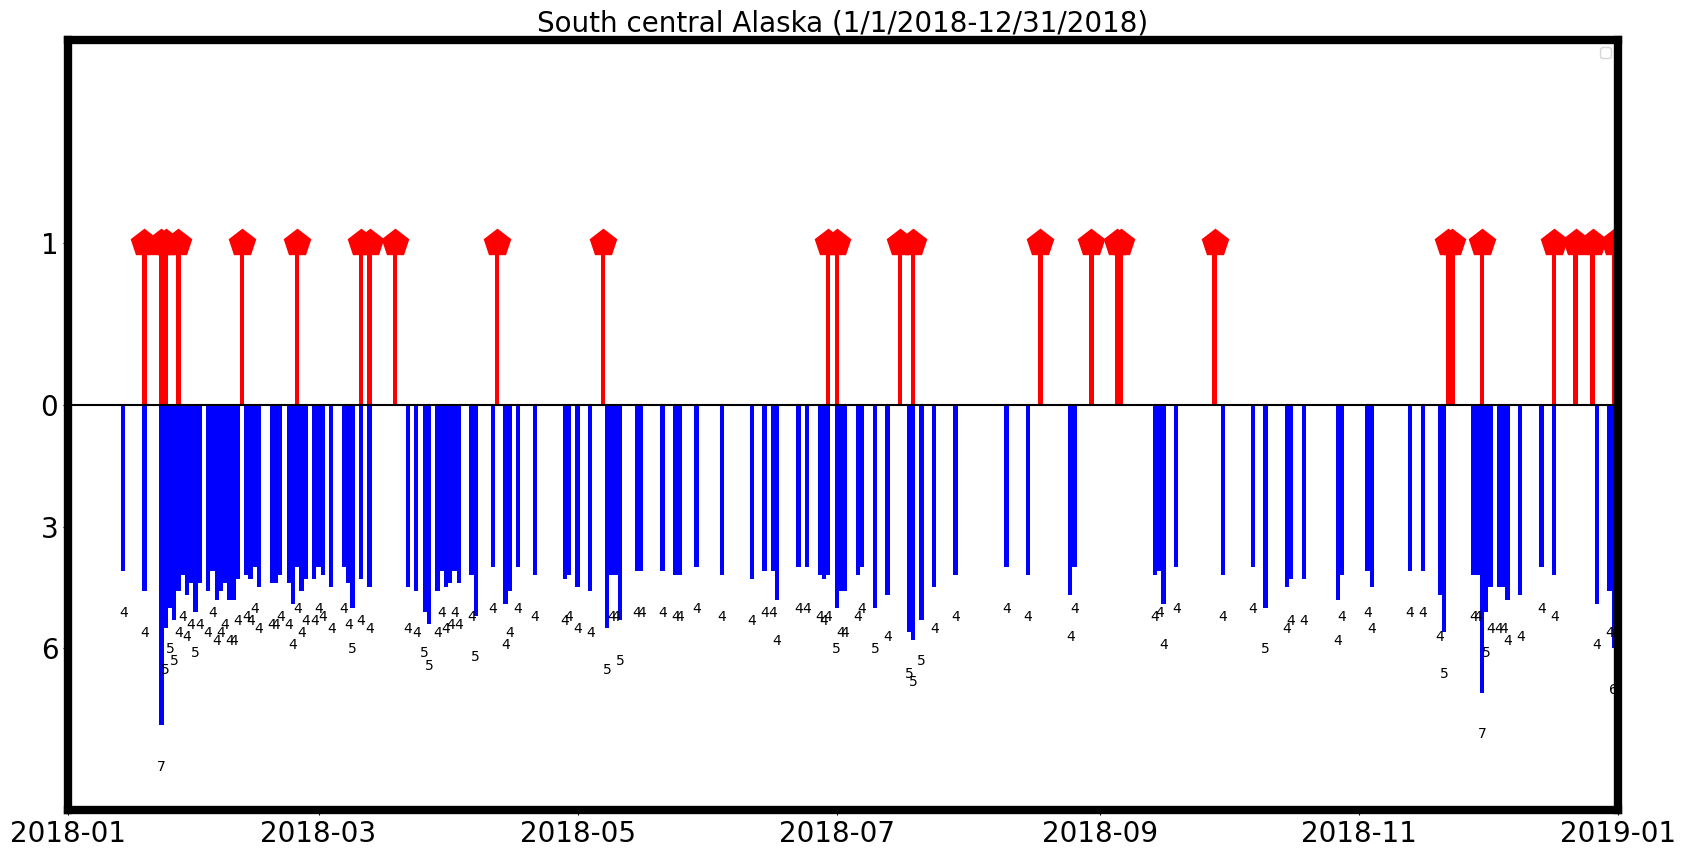

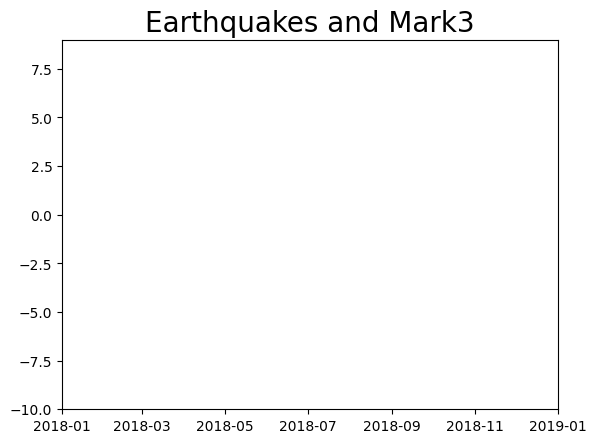

TP: 221
FN: 125
FP: 0.0
TN: 19.0
Precision: 1.0
TPR (Sensitivity): 0.638728323699422
FPR: 0.0
Specificity: 1.0
Accuracy: 0.6575342465753424
Error Rate: 0.3424657534246575


In [25]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2

# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()

# 设置图形属性
plt.title('Earthquakes and Mark3', fontsize=20)
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

# 显示图形
plt.show()

# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)

In [26]:
import pickle

In [27]:
mark1 = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/mark1.pkl', 'rb'))
mark3 = pickle.load(open('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/mark3.pkl', 'rb'))

In [28]:
mark1

array([ 17,  22,  23,  26,  39,  54,  69,  71,  77, 101, 126, 175, 181,
       196, 199, 227, 241, 247, 248, 268, 325, 326, 333, 340, 342, 343,
       355, 359, 364])

In [29]:
mark3

array([ 18,  19,  41,  47,  48,  49,  60,  61,  62,  73,  75,  76,  77,
        78,  95,  98, 100, 114, 121, 122, 141, 149, 150, 153, 179, 181,
       188, 190, 193, 200, 203, 229, 238, 239, 242, 243, 252, 253, 270,
       276, 317, 320, 350, 352])

In [30]:
South_central_Alaska_earthquake_event = earthquake_data

# 处理地震矩阵，只保留震级大于等于5的地震
earthquake_matrix = South_central_Alaska_earthquake_event[0, :].copy()
earthquake_matrix[earthquake_matrix < 3] = 0
Y2 = earthquake_matrix
Y2 = earthquake_matrix
np.where(Y2 != 0)[0]

array([  2,   6,   8,  10,  13,  14,  16,  17,  18,  19,  20,  21,  22,
        23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,
        36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,
        49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
        75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 160, 161, 162, 163, 164, 165, 166,
       167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
       180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 19

In [31]:
ydata = np.random.rand(365)
mark = []
for m in mark1:
    a = max(0, m - 14)
    b = min(len(ydata)-1, m)
    c = min(len(ydata)-1, m + 14)
    for mk in mark3:
        if a <= mk <= b:
            mark.append(m)
            break
        elif b < mk <= c:
            mark.append(mk)
            break
mark = np.unique(mark)

# 创建 single 数组
single = np.zeros(len(ydata))
single[mark] = 1

# 初始化变量
starday = 0
earthquake = 0
acuur_single = np.zeros(len(single))
accur_earthqu = []

for i in range(starday, len(Y2)):
    if Y2[i] != 0:
        earthquake += 1
        a = max(0, i - 14)
        b = min(len(ydata)-1, i)
        if np.any(single[a:b+1] == 1):
            accur_earthqu.append(i)
            acuur_single[np.where(single[a:b+1] == 1)[0] + a] = 1
accur_earthqu = np.unique(accur_earthqu)

# 计算 acuur_mark
acuur_mark = np.where(acuur_single == 1)[0]
TP = len(accur_earthqu)
FN = earthquake - TP

# 计算 erro_single
erro_single = single.copy()
for mmm in accur_earthqu:
    a = max(0, mmm - 14)
    b = min(len(ydata)-1, mmm)
    erro_single[a:b+1][single[a:b+1] == 1] = 0

# 计算 erro_mark
erro_mark = np.where(erro_single == 1)[0]

# 计算 FP 和 TN
FP = np.sum(erro_single[starday:])
TN = len(ydata[starday:]) - earthquake - FP

# 计算评估指标
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0
TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
Specificity = TN / (FP + TN) if (FP + TN) > 0 else 0
Accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
error = (FP + FN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

# 调整 acuur_single 和 erro_single 以便绘图
acuur_single[acuur_single != 0] = 4
erro_single[erro_single != 0] = 4

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


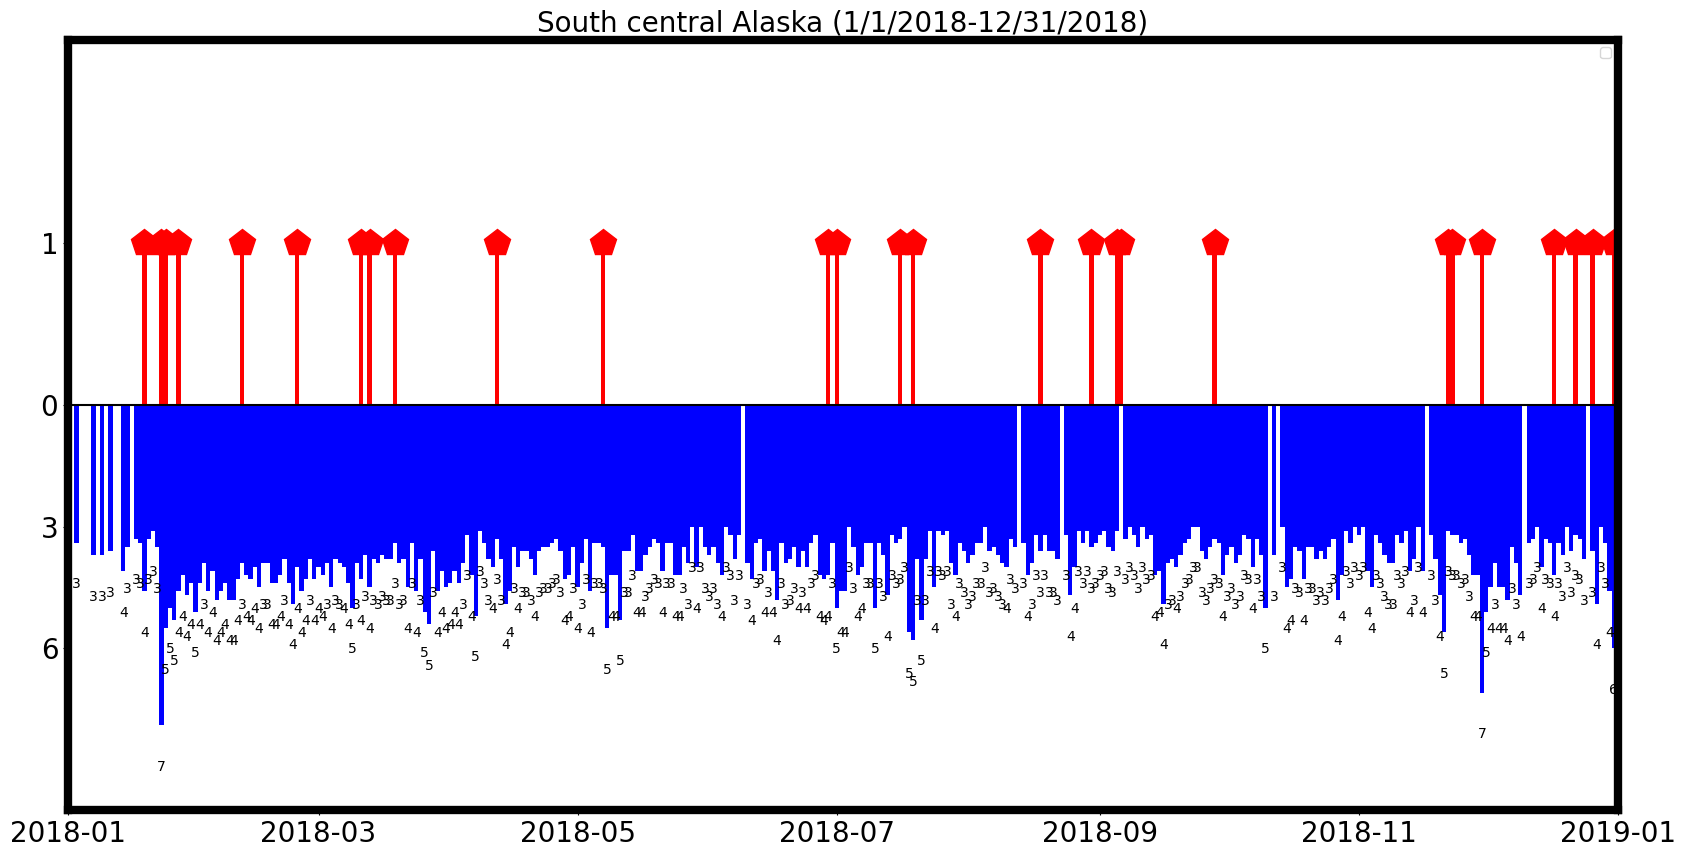

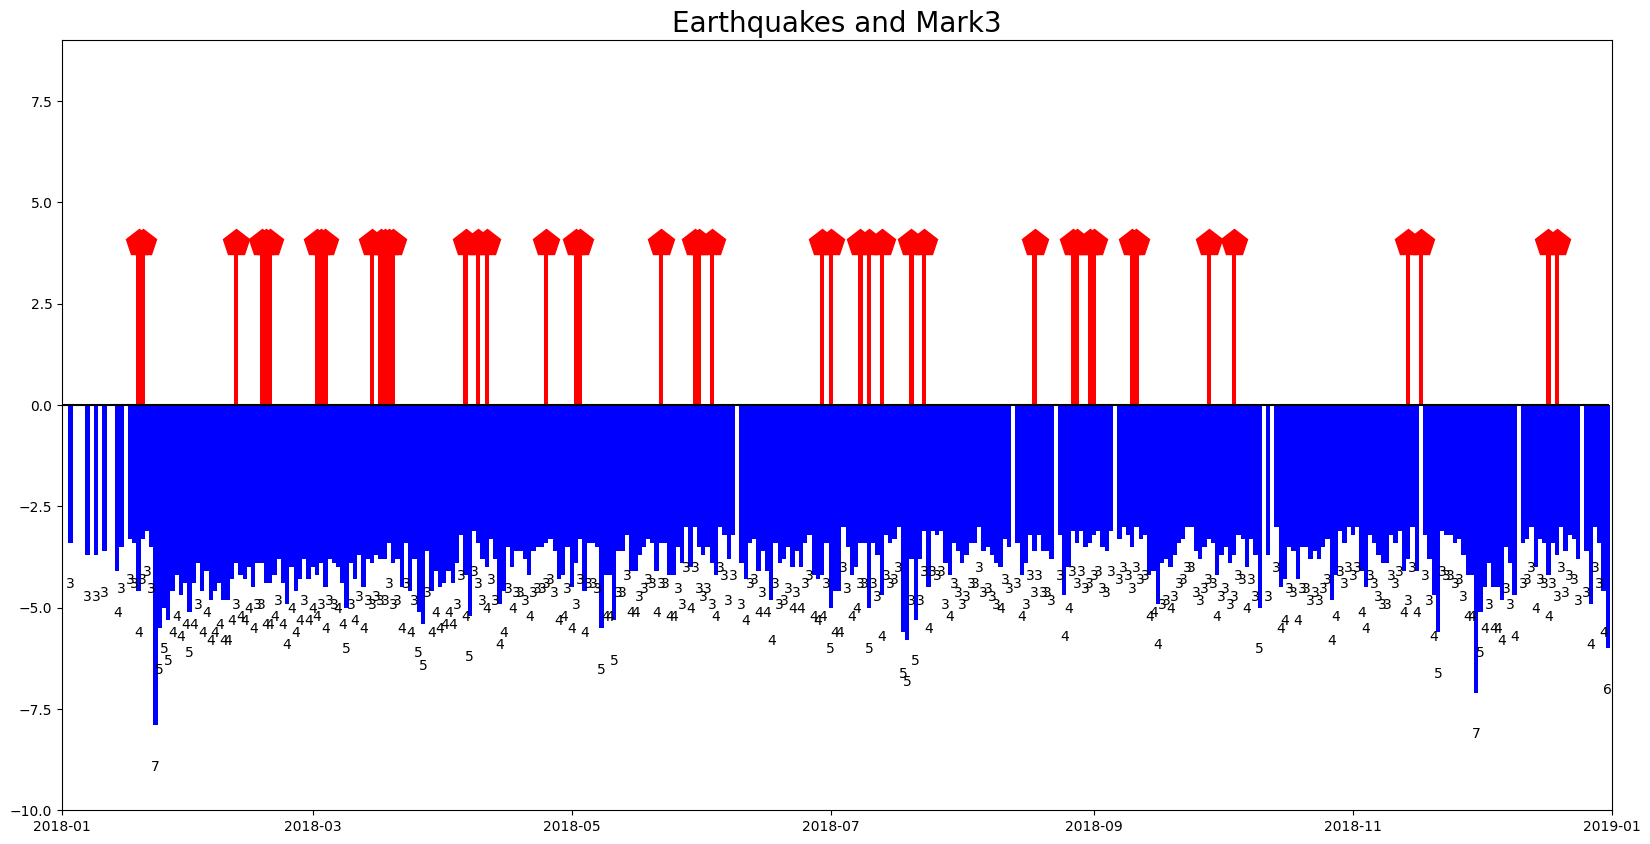

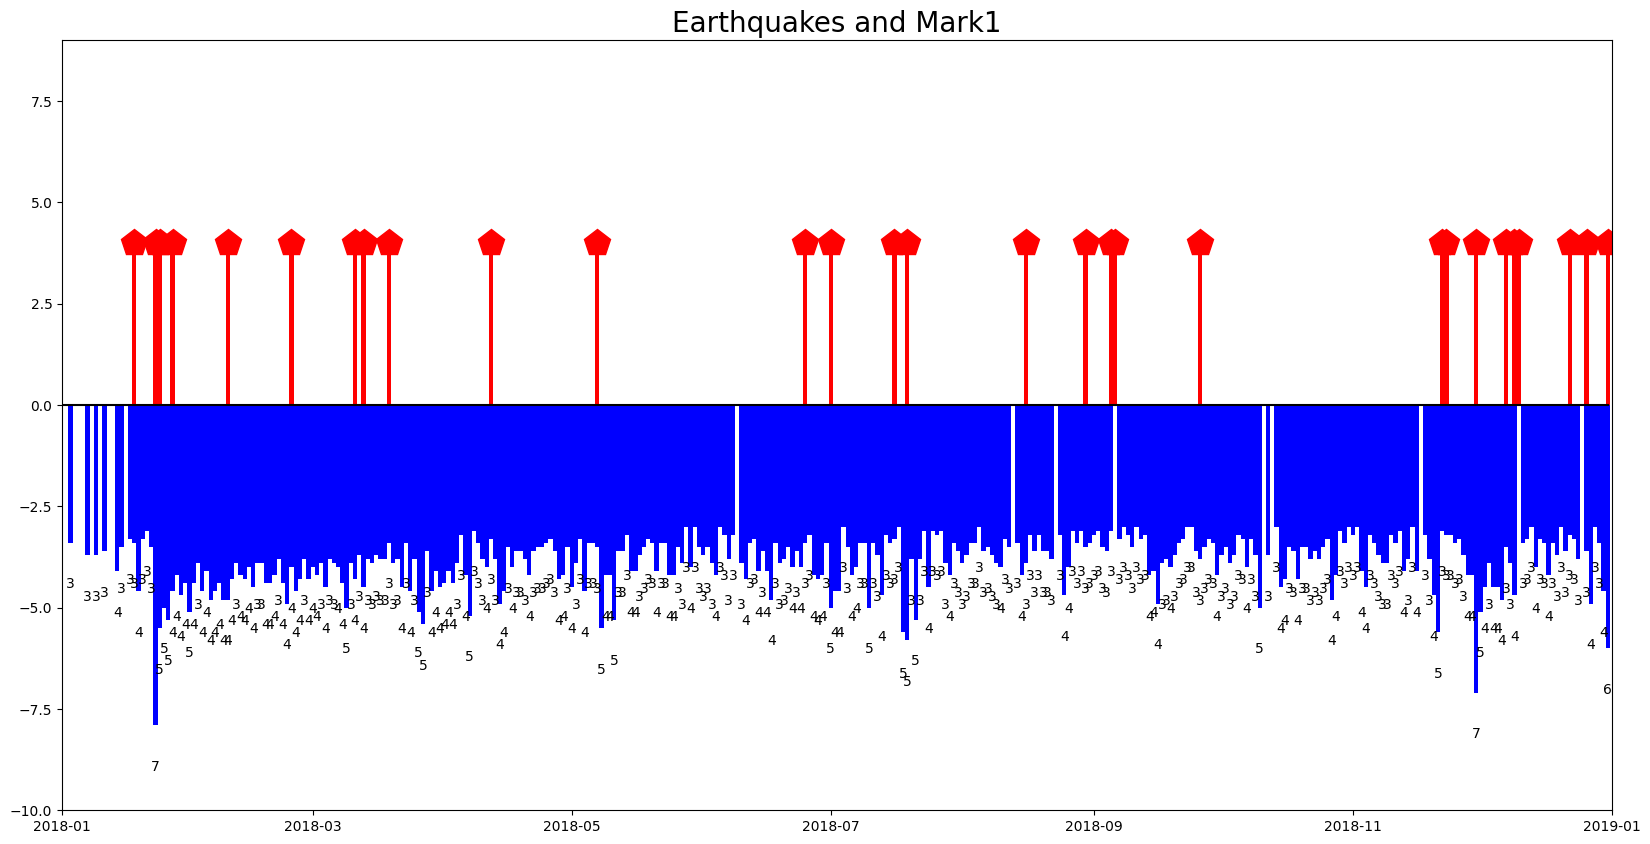

TP: 221
FN: 125
FP: 0.0
TN: 19.0
Precision: 1.0
TPR (Sensitivity): 0.638728323699422
FPR: 0.0
Specificity: 1.0
Accuracy: 0.6575342465753424
Error Rate: 0.3424657534246575


In [32]:
# 绘制原始图形，并添加 mark1 和 mark3
plt.figure(figsize=(20, 10))
t_start = datetime(2018, 1, 1)
t_long = t_start
t1 = np.array([t_long + timedelta(days=i) for i in range(len(ydata))])
demo = np.zeros(len(ydata))  # 确保 demo 的长度与 ydata 一致
plt.plot(t1, demo, color='k')

# 绘制 acuur_single
plt.bar(t1[starday:], acuur_single[starday:], color='r', width=1)

# 设置图形属性
plt.tick_params(axis='both', which='major', labelsize=20)
plt.yticks([-6, -3, 0, 4], ['6', '3', '0', '1'])
plt.gca().spines['top'].set_linewidth(6)
plt.gca().spines['right'].set_linewidth(6)
plt.gca().spines['bottom'].set_linewidth(6)
plt.gca().spines['left'].set_linewidth(6)

# 标题
plt.title('South central Alaska (1/1/2018-12/31/2018)', fontsize=20)

# 绘制 erro_single
plt.bar(t1[starday:], erro_single[starday:], color=[0.5, 0.5, 0.5], width=1)

# 绘制 erro_mark 点
for idx in erro_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor=[0.5, 0.5, 0.5], markeredgecolor=[0.5, 0.5, 0.5], linewidth=2)

# 准备 Y4 以便绘制地震
Y4 = -Y2
t_es = np.array([t_long + timedelta(days=i) for i in range(len(Y2))])    # 地震事件的日期
# 添加地震的文本标签
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)

# 绘制地震
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)

# 绘制 acuur_mark 点
for idx in acuur_mark:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)


# 设置坐标轴范围
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

# 添加图例
plt.legend()

# 显示图形
plt.show()

plt.figure(figsize=(20, 10))
# 设置图形属性
plt.title('Earthquakes and Mark3', fontsize=20)
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])

mark3_single = np.zeros(len(ydata))
mark3_single[mark3] = 4
plt.plot(t1, demo, color='k')
plt.bar(t1, mark3_single, color='r', width=1)
for idx in mark3:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)

for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)
# 显示图形
plt.show()

plt.figure(figsize=(20, 10))
# 设置图形属性
plt.title('Earthquakes and Mark1', fontsize=20)
plt.xlim([datetime(2018, 1, 1), datetime(2019, 1, 1)])
plt.ylim([-10, 9])
mark1_single = np.zeros(len(ydata))
mark1_single[mark1] = 4
plt.plot(t1, demo, color='k')
plt.bar(t1, mark1_single, color='r', width=1)
for idx in mark1:
    if idx >= starday:
        x = t1[idx]
        y = 4
        plt.plot(x, y, 'p', markersize=20, markerfacecolor='r', markeredgecolor='r', linewidth=2)
plt.bar(t_es[starday:], Y4[starday:], color='b', width=1)
for i in range(starday, len(Y4)):
    if Y4[i] != 0:
        plt.text(t_es[i], Y4[i]-1.2, str(int(-Y4[i])), verticalalignment='bottom', horizontalalignment='center', fontsize=10)
# 显示图形
plt.show()

# 准备 AAAA
AAAA = [TP, FN, FP, TN, Precision, TPR, FPR, Specificity, Accuracy, error]
warning_effect = AAAA

# 输出结果
print('TP:', TP)
print('FN:', FN)
print('FP:', FP)
print('TN:', TN)
print('Precision:', Precision)
print('TPR (Sensitivity):', TPR)
print('FPR:', FPR)
print('Specificity:', Specificity)
print('Accuracy:', Accuracy)
print('Error Rate:', error)